# ARIMA Model Selection



In [5]:
# ARIMA Modeling (1)

if (!require("tidyverse")) install.packages("tidyverse")
if (!require("eurostat")) install.packages("eurostat")
if (!require("tsibble")) install.packages("tsibble")
if (!require("fable")) install.packages("fable")
if (!require("fabletools")) install.packages("fabletools")
if (!require("feasts")) install.packages("feasts")

library(tidyverse)
library(eurostat)
library(tsibble)
library(fable)
library(fabletools)
library(feasts)


In [ ]:
gdp <- get_eurostat(
  "namq_10_gdp",
  filters = list(
    geo="BG",
    unit = "CLV15_MEUR",
    na_item = "B1GQ",
    s_adj = "NSA"
  ),
  cache = FALSE,
  type = "code"
) |>
  filter(!is.na(values)) |>
  mutate(
    q = yearquarter(str_replace(time, "-", " ")),
    values = as.numeric(values)
  ) |>
  as_tsibble(index = q) |>
  select(values)


In [ ]:
gdp |>
  index_by(Year = ~ year(.)) |>
  summarise(
    GDP = sum(values)
  ) |> tail()

Year,GDP
<dbl>,<dbl>
2021,53781.4
2022,55977.8
2023,56919.0
2024,58847.0
2025,60669.1
2026,12605.7


Warning message:
“`autoplot.tbl_ts()` was deprecated in fabletools 0.6.0.
ℹ Please use `ggtime::autoplot.tbl_ts()` instead.
ℹ Graphics functions have been moved to the {ggtime} package. Please use
  `library(ggtime)` instead.”


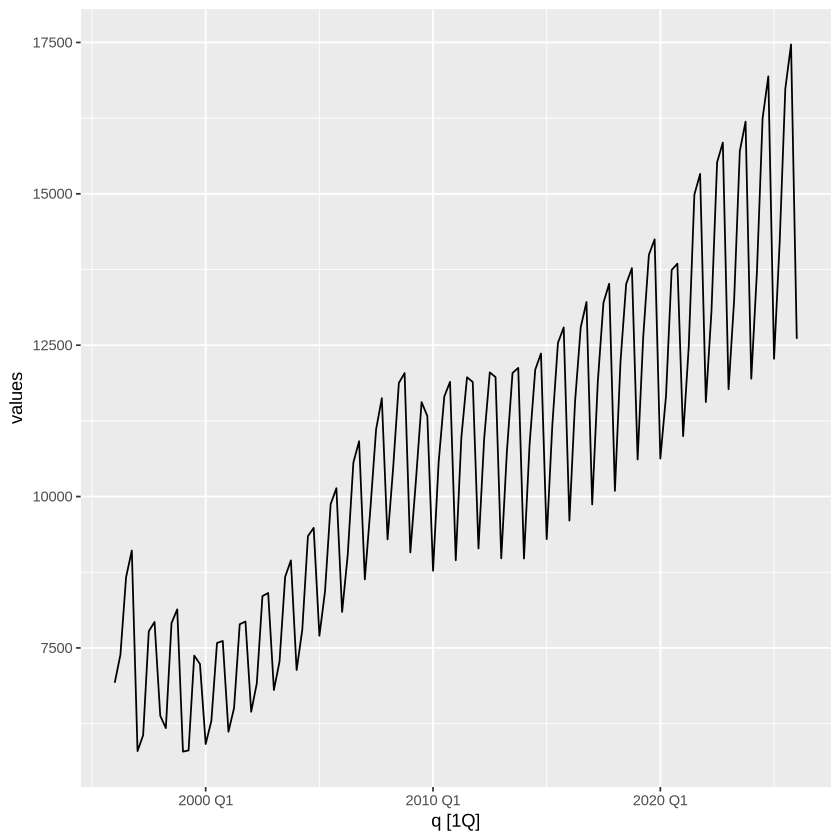

In [9]:
gdp |>
  autoplot(values)

In [11]:
gdp <- gdp |>
  mutate(
    growth1 = log(values) - log(lag(values))
  ) |>
  filter(!is.na(growth1))

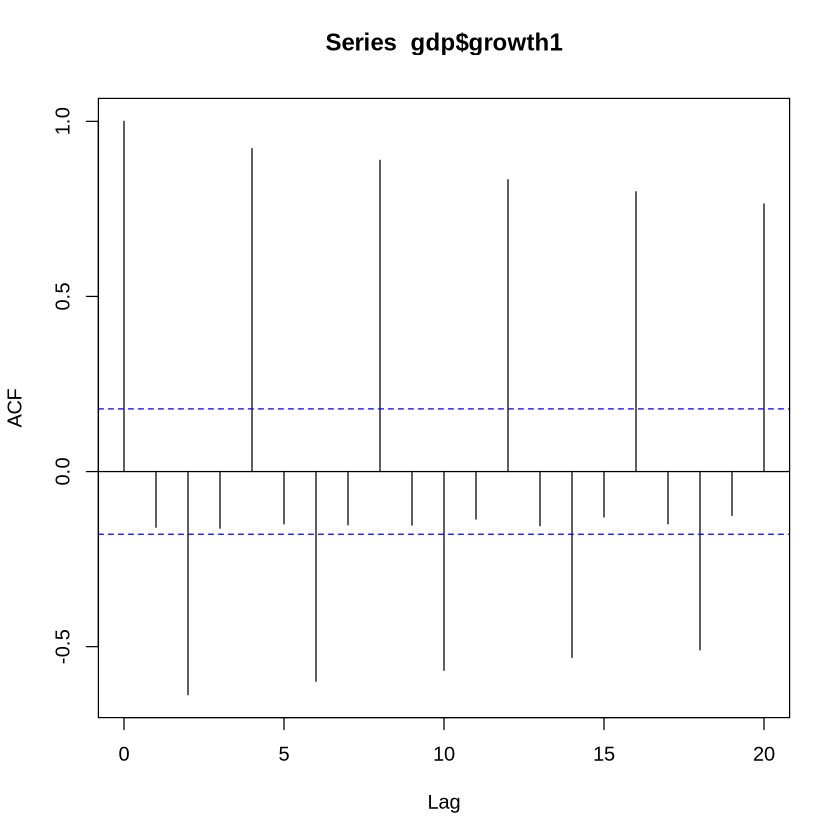

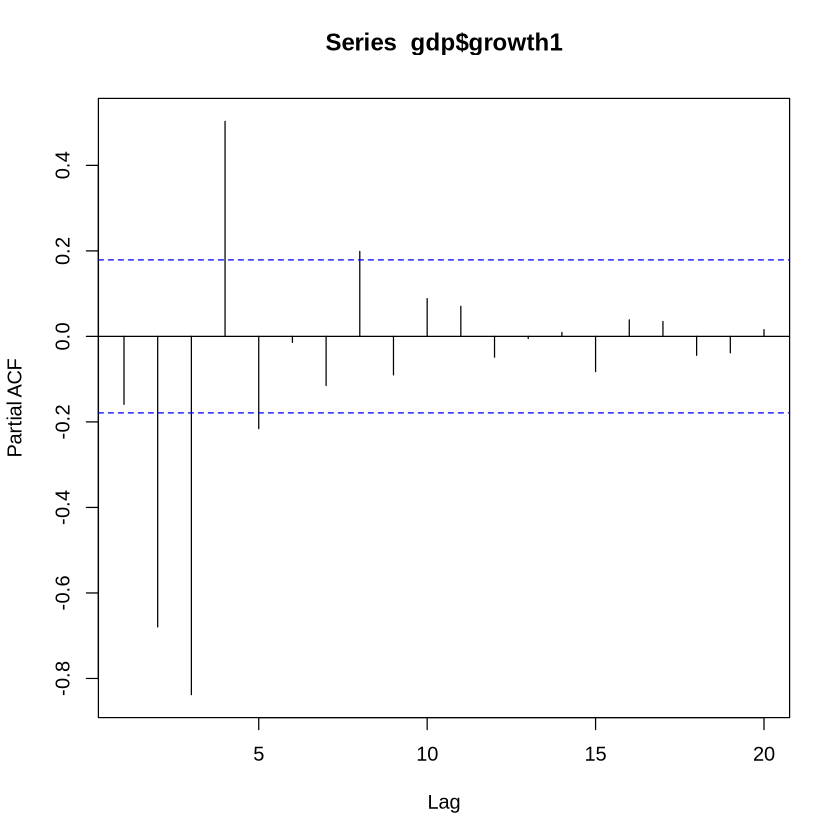

In [12]:
acf(gdp$growth1, na.action = na.pass)
pacf(gdp$growth1, na.action = na.pass)